# Notebook 06 – Model Improvement and Experiments

## Objective

The goal of this notebook is to improve the performance of the fine-tuned BERT model through systematic experiments.

Unlike the previous notebooks, this notebook focuses on comparing different training strategies and analyzing their impact on model performance.

Experiments include:

- Increasing the number of training epochs
- Comparing evaluation metrics
- Analyzing improvements
- Selecting the best-performing model

## Experiment 1 – Increasing the Number of Epochs

### Hypothesis

Training the model for more epochs may improve its ability to learn meaningful patterns from the training data, resulting in higher recall and F1-score.

However, excessive training may also increase the risk of overfitting.

## Experiment 1 – Additional Fine-Tuning

### Goal

Evaluate whether training the model for additional epochs improves the overall classification performance.

### Hypothesis

Training for three additional epochs will improve the model's ability to recognize complex language patterns, particularly in the Depression and Suicidal classes.

### Metrics

The following metrics will be compared with the baseline model:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

### Success Criteria

The experiment will be considered successful if the recall and F1-score of the Suicidal class improve without a significant decrease in overall performance.

## Load Previous Checkpoint

The best checkpoint from Notebook 04 is loaded to continue fine-tuning without restarting the training process.

Both the model parameters and optimizer state are restored.

In [7]:
import torch
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW

In [9]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(device)

mps


In [ ]:
NUM_LABELS = 4

MODEL_PATH = "../models/bert_mental_health"

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

model.to(device)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
)

## Rebuild Data Pipeline

The processed train, validation, and test datasets are reloaded to continue
fine-tuning and model improvement experiments.

The same label mapping, tokenizer configuration, and dataset structure used
during the original BERT fine-tuning are preserved for consistency.

In [16]:
from pathlib import Path
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

PROCESSED_DATA_DIR = Path("../data/processed")

train_df = pd.read_csv(PROCESSED_DATA_DIR / "train.csv")
validation_df = pd.read_csv(PROCESSED_DATA_DIR / "validation.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")

print("Training set:", train_df.shape)
print("Validation set:", validation_df.shape)
print("Test set:", test_df.shape)

Training set: (34254, 2)
Validation set: (7340, 2)
Test set: (7341, 2)


In [17]:
label2id = {
    "Anxiety": 0,
    "Depression": 1,
    "Normal": 2,
    "Suicidal": 3,
}

id2label = {v: k for k, v in label2id.items()}

for dataframe in [train_df, validation_df, test_df]:
    dataframe["label"] = dataframe["status"].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

label2id: {'Anxiety': 0, 'Depression': 1, 'Normal': 2, 'Suicidal': 3}
id2label: {0: 'Anxiety', 1: 'Depression', 2: 'Normal', 3: 'Suicidal'}


In [18]:
MODEL_PATH = "../models/bert_mental_health"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)

MAX_LENGTH = 128

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [23]:
BATCH_SIZE = 16

train_dataset = MentalHealthDataset(
    dataframe=train_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
)

validation_dataset = MentalHealthDataset(
    dataframe=validation_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
)

test_dataset = MentalHealthDataset(
    dataframe=test_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Train batches: 2141
Validation batches: 459
Test batches: 459


In [21]:
class MentalHealthDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_length: int = 128,
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        text = self.dataframe.iloc[index]["text"]
        label = self.dataframe.iloc[index]["label"]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

In [22]:
batch = next(iter(train_loader))

print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["labels"].shape)

print("First labels:", batch["labels"][:5])

NameError: name 'train_loader' is not defined

In [ ]:
start_epoch = 0
TOTAL_EPOCHS = 1

In [ ]:
model.train()

for epoch in range(start_epoch, TOTAL_EPOCHS):

    total_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1}")
    print(f"Average Loss: {avg_loss:.4f}")

Epoch 1
Average Loss: 0.4756


In [ ]:
print("start_epoch:", start_epoch)
print("TOTAL_EPOCHS:", TOTAL_EPOCHS)
print("Epoch values:", list(range(start_epoch, TOTAL_EPOCHS)))

start_epoch: 0
TOTAL_EPOCHS: 1
Epoch values: [0]


In [ ]:
ADDITIONAL_EPOCHS = 2

model.train()

for epoch in range(ADDITIONAL_EPOCHS):

    total_loss = 0.0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Additional Epoch {epoch + 1}")
    print(f"Average Loss: {avg_loss:.4f}")

Additional Epoch 1
Average Loss: 0.3246
Additional Epoch 2
Average Loss: 0.2262


### Continued Fine-Tuning

The model had already completed one training epoch in the current session.

Therefore, two additional epochs were performed to reach approximately three epochs of total fine-tuning.

The objective is to evaluate whether continued training improves class-specific performance, especially recall and F1-score for the Suicidal class.

In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=1,
        )

        all_predictions.extend(predictions.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

print("Evaluation completed.")
print("Predictions:", len(all_predictions))

Evaluation completed.
Predictions: 7341


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
accuracy = accuracy_score(
    all_labels,
    all_predictions,
)

print(f"Accuracy: {accuracy:.4f}")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Anxiety",
            "Depression",
            "Normal",
            "Suicidal",
        ],
        digits=4,
    )
)

Accuracy: 0.8431
              precision    recall  f1-score   support

     Anxiety     0.8072    0.9011    0.8516       799
  Depression     0.7638    0.7892    0.7763      2139
      Normal     0.9577    0.9490    0.9533      2723
    Suicidal     0.7768    0.7125    0.7432      1680

    accuracy                         0.8431      7341
   macro avg     0.8264    0.8379    0.8311      7341
weighted avg     0.8434    0.8431    0.8426      7341



In [ ]:
print(len(train_df))
print(len(validation_df))
print(len(test_df))

34254
7340
7341


In [ ]:
print(len(train_loader.dataset))
print(len(test_loader.dataset))

34254
7341


## Experiment 1 Result

Additional fine-tuning improved the model substantially.

Accuracy increased from 68.49% to 84.31%. The recall of the Suicidal class improved from 64.29% to 71.25%, while its F1-score increased from 58.60% to 74.32%.

The experiment suggests that the initial checkpoint had not yet converged and that additional fine-tuning allowed the model to learn more useful patterns. However, validation performance should also be monitored to detect potential overfitting.

# Experiment 1 Summary

## Objective

Evaluate whether additional fine-tuning improves the performance of the BERT classifier.

## Results

| Metric | Baseline | Experiment 1 |
|---------|----------|--------------|
| Accuracy | 68.49% | 84.31% |
| Suicidal Recall | 64.29% | 71.25% |
| Suicidal F1 | 58.60% | 74.32% |

## Interpretation

Additional fine-tuning significantly improved the model performance.

The largest improvements were observed across multiple classes while maintaining strong performance for the Normal class.

Most importantly, recall and F1-score for the Suicidal class improved, which is particularly valuable in mental health applications.

Future experiments will investigate learning rate, batch size, and class weighting.

## Limitations

The current experiment evaluates the impact of additional fine-tuning.

Although the results improved substantially, further experiments are required to evaluate:

- different learning rates,
- batch sizes,
- class weighting,
- early stopping,
- and validation performance across multiple training runs.

These experiments will be presented in the following notebook.

## Experiment 2 – Lower Learning Rate

### Goal

Evaluate whether a smaller learning rate improves the fine-tuning stability and generalization performance of the BERT classifier.

### Hypothesis

Reducing the learning rate from `2e-5` to `1e-5` may allow the model to update its pre-trained parameters more carefully and potentially improve generalization.

### Controlled Variables

The dataset, model architecture, batch size, preprocessing pipeline, and number of training epochs will remain unchanged.

Only the learning rate will be modified.

### Evaluation Criteria

The experiment will be compared with Experiment 1 using:

- Accuracy
- Precision
- Recall
- F1-score
- Suicidal Recall
- Suicidal F1-score

In [2]:
from pathlib import Path
import os

MODEL_CACHE_DIR = Path("../models/hf_cache").resolve()
MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(MODEL_CACHE_DIR)
os.environ["HF_HUB_CACHE"] = str(MODEL_CACHE_DIR / "hub")
os.environ["HF_HUB_DISABLE_XET"] = "1"

print("Model cache:", MODEL_CACHE_DIR)

Model cache: /Users/Guclu002/Desktop/mental-health-bert-classification/models/hf_cache


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4,
    cache_dir=MODEL_CACHE_DIR,
)

model = model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
print("Model loaded successfully!")
print("Model device:", next(model.parameters()).device)

Model loaded successfully!
Model device: mps:0


In [12]:
optimizer = AdamW(
    model.parameters(),
    lr=1e-5,
)

print("Optimizer created.")
print("Learning rate:", optimizer.param_groups[0]["lr"])

Optimizer created.
Learning rate: 1e-05


In [13]:
NUM_EPOCHS = 3

In [24]:
model.train()

for epoch in range(NUM_EPOCHS):

    total_loss = 0.0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1}")
    print(f"Average Loss: {avg_loss:.4f}")

Epoch 1
Average Loss: 0.5311
Epoch 2
Average Loss: 0.3535
Epoch 3
Average Loss: 0.2661


In [25]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=1,
        )

        all_predictions.extend(predictions.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

print("Evaluation completed.")
print("Number of predictions:", len(all_predictions))

Evaluation completed.
Number of predictions: 7341


In [26]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(
    all_labels,
    all_predictions,
)

print(f"Accuracy: {accuracy:.4f}")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Anxiety",
            "Depression",
            "Normal",
            "Suicidal",
        ],
        digits=4,
    )
)

Accuracy: 0.8424
              precision    recall  f1-score   support

     Anxiety     0.8357    0.8723    0.8536       799
  Depression     0.7756    0.7625    0.7690      2139
      Normal     0.9431    0.9611    0.9520      2723
    Suicidal     0.7606    0.7375    0.7489      1680

    accuracy                         0.8424      7341
   macro avg     0.8287    0.8334    0.8309      7341
weighted avg     0.8408    0.8424    0.8415      7341



### Experiment 2 – Interpretation

Reducing the learning rate from `2e-5` to `1e-5` produced almost identical
overall accuracy (84.31% vs. 84.24%).

However, Suicidal recall increased from 71.25% to 73.75%, and Suicidal
F1-score increased from 74.32% to 74.89%.

This suggests that the lower learning rate provided a slightly more favorable
trade-off for the clinically important Suicidal class, despite a very small
decrease in overall accuracy.

Because hyperparameter selection should ideally be based on validation data,
future experiments will use the validation set for model selection and reserve
the test set for final evaluation.

In [27]:
SAVE_PATH = "../models/bert_lr_1e-5"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Experiment 2 model saved to:", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Experiment 2 model saved to: ../models/bert_lr_1e-5


In [28]:
from sklearn.metrics import confusion_matrix

cm_exp2 = confusion_matrix(all_labels, all_predictions)

print(cm_exp2)

[[ 697   61   34    7]
 [  79 1631   66  363]
 [  45   41 2617   20]
 [  13  370   58 1239]]


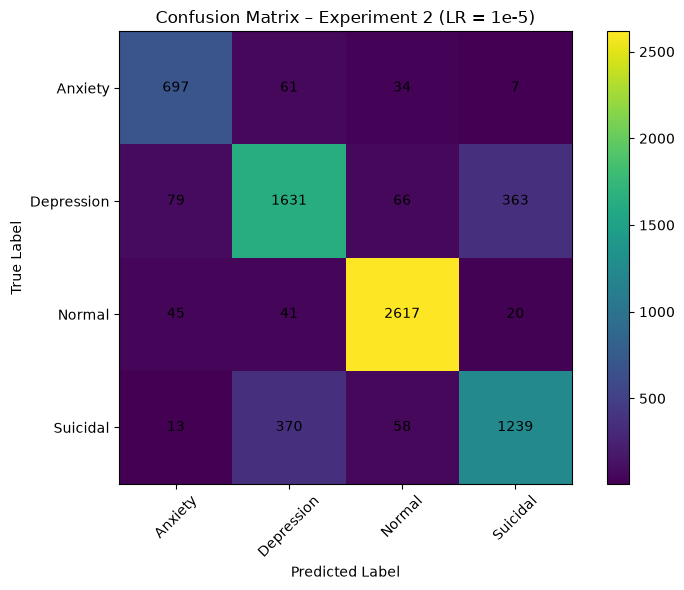

In [29]:
import matplotlib.pyplot as plt

classes = ["Anxiety", "Depression", "Normal", "Suicidal"]

plt.figure(figsize=(8, 6))
plt.imshow(cm_exp2)
plt.colorbar()

plt.xticks(range(len(classes)), classes, rotation=45)

plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Experiment 2 (LR = 1e-5)")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm_exp2[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

The main remaining classification challenge is the distinction between
Depression and Suicidal texts.

Among 1,680 true Suicidal samples, 1,239 were correctly classified,
corresponding to a recall of 73.75%. However, 370 Suicidal samples were
misclassified as Depression.

A similar pattern was observed in the opposite direction, with 363
Depression samples classified as Suicidal.

This suggests substantial overlap between the linguistic patterns of the
Depression and Suicidal classes. Future improvements should therefore focus
not only on overall model performance, but specifically on improving the
separation between these two clinically related classes.

## Experiment 3 – Class Weighting

### Goal

Evaluate whether class-weighted training can improve the detection of the
Suicidal class, particularly by reducing false negatives.

### Hypothesis

Assigning a higher loss penalty to errors involving the Suicidal class may
increase Suicidal recall. However, this may also increase false positives and
reduce precision.

### Evaluation

The experiment will focus on:

- Suicidal Recall
- Suicidal Precision
- Suicidal F1-score
- Overall Accuracy
- Confusion Matrix

In [30]:
train_df["status"].value_counts()

status
Normal        12706
Depression     9981
Suicidal       7840
Anxiety        3727
Name: count, dtype: int64

In [31]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

classes = np.array(["Anxiety", "Depression", "Normal", "Suicidal"])

class_weights = compute_class_weight(
    class_weight="balanced", classes=classes, y=train_df["status"]
)

print("Class weights:")

for label, weight in zip(classes, class_weights):
    print(f"{label}: {weight:.4f}")

Class weights:
Anxiety: 2.2977
Depression: 0.8580
Normal: 0.6740
Suicidal: 1.0923


In [32]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights_tensor)

tensor([2.2977, 0.8580, 0.6740, 1.0923], device='mps:0')


In [33]:
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

In [34]:
outputs = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
)

loss = criterion(outputs.logits, labels)

In [35]:
variables_to_check = [
    "train_df",
    "train_loader",
    "test_loader",
    "tokenizer",
    "model",
    "class_weights",
    "class_weights_tensor",
    "device",
]

for var in variables_to_check:
    print(f"{var}:", "READY" if var in globals() else "MISSING")

train_df: READY
train_loader: READY
test_loader: READY
tokenizer: READY
model: READY
class_weights: READY
class_weights_tensor: READY
device: READY


In [36]:
from transformers import set_seed

set_seed(42)

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4,
    cache_dir=MODEL_CACHE_DIR,
)

model = model.to(device)

print("Fresh model loaded.")
print("Device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model loaded.
Device: mps:0


In [37]:
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = AdamW(model.parameters(), lr=1e-5)

print("Weighted loss ready.")
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Class weights:", class_weights_tensor)

Weighted loss ready.
Learning rate: 1e-05
Class weights: tensor([2.2977, 0.8580, 0.6740, 1.0923], device='mps:0')


In [38]:
NUM_EPOCHS = 3

model.train()

for epoch in range(NUM_EPOCHS):

    total_loss = 0.0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1} " f"Average Weighted Loss: {avg_loss:.4f}")

Epoch 1 Average Weighted Loss: 0.5613
Epoch 2 Average Weighted Loss: 0.3626
Epoch 3 Average Weighted Loss: 0.2662


In [39]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        predictions = torch.argmax(outputs.logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

print("Evaluation completed.")
print("Predictions:", len(all_predictions))

Evaluation completed.
Predictions: 7341


In [40]:
accuracy = accuracy_score(all_labels, all_predictions)

print(f"Accuracy: {accuracy:.4f}")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Anxiety",
            "Depression",
            "Normal",
            "Suicidal",
        ],
        digits=4,
    )
)

Accuracy: 0.8406
              precision    recall  f1-score   support

     Anxiety     0.8182    0.8899    0.8525       799
  Depression     0.8297    0.6877    0.7520      2139
      Normal     0.9660    0.9299    0.9476      2723
    Suicidal     0.7012    0.8673    0.7754      1680

    accuracy                         0.8406      7341
   macro avg     0.8288    0.8437    0.8319      7341
weighted avg     0.8496    0.8406    0.8409      7341



### Experiment 3A – Interpretation

Automatic class weighting produced a substantial improvement in the recall
of the Suicidal class, increasing it from 73.75% to 86.73%.

Suicidal F1-score also improved from 74.89% to 77.54%, while overall
accuracy remained relatively stable (84.24% vs. 84.06%).

However, this improvement involved an important trade-off. Suicidal
precision decreased from 76.06% to 70.12%, while Depression recall
decreased from 76.25% to 68.77%.

These results suggest that class weighting reduced false negatives for the
Suicidal class but also increased false positives and changed the error
distribution across classes.

In a mental-health application where missing potentially suicidal cases may
have a higher cost than additional false positives, this trade-off could be
valuable. However, the appropriate operating point would need to be defined
with clinical stakeholders and validated carefully before real-world use.

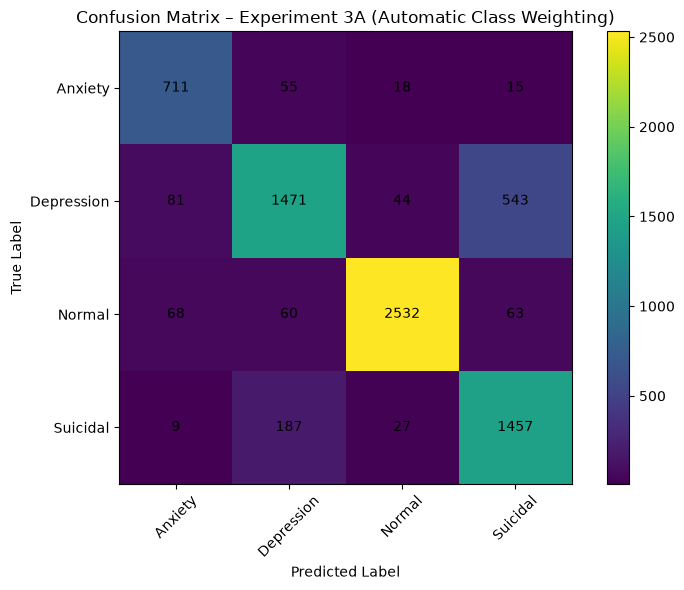

In [41]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_exp3a = confusion_matrix(all_labels, all_predictions)

classes = ["Anxiety", "Depression", "Normal", "Suicidal"]

plt.figure(figsize=(8, 6))
plt.imshow(cm_exp3a)
plt.colorbar()

plt.xticks(range(len(classes)), classes, rotation=45)

plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Experiment 3A (Automatic Class Weighting)")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm_exp3a[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [42]:
SAVE_PATH = "../models/bert_lr1e-5_auto_class_weights"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Experiment 3A model saved:", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Experiment 3A model saved: ../models/bert_lr1e-5_auto_class_weights


In [43]:
import numpy as np

y_true = np.array(all_labels)
y_pred = np.array(all_predictions)

# Label mapping:
# 0 = Anxiety
# 1 = Depression
# 2 = Normal
# 3 = Suicidal

suicidal_as_depression = np.where((y_true == 3) & (y_pred == 1))[0]

depression_as_suicidal = np.where((y_true == 1) & (y_pred == 3))[0]

print("Suicidal → Depression:", len(suicidal_as_depression))

print("Depression → Suicidal:", len(depression_as_suicidal))

Suicidal → Depression: 187
Depression → Suicidal: 543


In [44]:
# Suicidal → Depression examples

print("TRUE: Suicidal | PREDICTED: Depression\n")

for idx in suicidal_as_depression[:5]:
    print("-" * 80)
    print(test_df.iloc[idx]["text"])
    print()

TRUE: Suicidal | PREDICTED: Depression

--------------------------------------------------------------------------------
There was a narcissist(s) in my life, slowly trying to destroy me. It took me a while to realize.. they were trying to steal my friends, copy my personality. They would slowly chip away at my self-esteem and even try to turn others against me(spreading rumors, etc.) I feel so free now that I have no contact with them. I moved, made new friends and deleted my personal social media. Yeah, life still gets hard and I get sad sometimes. But nothing is as bad as being involved with them. People really underestimate how insidious these people are. I finally figured out why my life was so bad

--------------------------------------------------------------------------------
I have had depression for about 15 years. Six years ago I was in hospital with severe depression and the aftermath of what I had consumed (bleach). My family found out about this then. I have been working 

In [45]:
# Depression → Suicidal examples

print("TRUE: Depression | PREDICTED: Suicidal\n")

for idx in depression_as_suicidal[:5]:
    print("-" * 80)
    print(test_df.iloc[idx]["text"])
    print()

TRUE: Depression | PREDICTED: Suicidal

--------------------------------------------------------------------------------
I cannot do it anymore please help me I want to kill myself

--------------------------------------------------------------------------------
I do not want to die as I am aware of what that will do to those unfortunate enough to care about me. I wish i could be removed as though i was not here and spare them the pain of me being gone the normal way and spared having to deal with my continued existence as a strain on their lives. At this point i realised as much i do not care about myself and lack the feeling i care for them suffering as a result of me but all these years have proven i cannot make that small part of me strong enough to change things for the better as even getting out of bed each day is an accomplishment. I wish i could be phased out.

--------------------------------------------------------------------------------
I want to end it but I am so afraid o

### Qualitative Error Analysis

Manual inspection of misclassified Depression and Suicidal examples revealed
that not all errors appear to originate from the model.

Several samples showed possible label inconsistencies. For example, some texts
labeled as Depression contained explicit suicidal statements, while some texts
labeled as Suicidal showed little or no apparent suicidal content.

Other examples were genuinely ambiguous, particularly texts expressing passive
death wishes, hopelessness, or severe depressive symptoms without explicit
suicidal intent.

These findings suggest that the observed Depression–Suicidal confusion may be
partly driven by label noise and label ambiguity in addition to model
limitations.

Future work should therefore include a systematic review of labeling criteria
and, where possible, expert re-annotation or inter-rater reliability assessment.

In [48]:
import pandas as pd
import numpy as np

# First 15 examples from each major error type
sd_idx = suicidal_as_depression[:15]
ds_idx = depression_as_suicidal[:15]

error_rows = []

for idx in sd_idx:
    error_rows.append(
        {
            "text": test_df.iloc[idx]["text"],
            "true_label": "Suicidal",
            "predicted_label": "Depression",
            "error_category": "",
        }
    )

for idx in ds_idx:
    error_rows.append(
        {
            "text": test_df.iloc[idx]["text"],
            "true_label": "Depression",
            "predicted_label": "Suicidal",
            "error_category": "",
        }
    )

error_analysis_df = pd.DataFrame(error_rows)

print("Number of samples:", len(error_analysis_df))

error_analysis_df.head()

Number of samples: 30


,text,true_label,predicted_label,error_category
0,"There was a narcissist(s) in my life, slowly t...",Suicidal,Depression,
1,I have had depression for about 15 years. Six ...,Suicidal,Depression,
2,"Do you think if you were born in another era, ...",Suicidal,Depression,
3,that is always what I wanted to do. I wanted t...,Suicidal,Depression,
4,Got in a big argument with my parents because ...,Suicidal,Depression,


In [49]:
for i, row in error_analysis_df.iterrows():
    print("=" * 90)
    print(f"SAMPLE {i}")
    print(f"TRUE LABEL     : {row['true_label']}")
    print(f"PREDICTED LABEL: {row['predicted_label']}")
    print("-" * 90)
    print(row["text"])
    print()

SAMPLE 0
TRUE LABEL     : Suicidal
PREDICTED LABEL: Depression
------------------------------------------------------------------------------------------
There was a narcissist(s) in my life, slowly trying to destroy me. It took me a while to realize.. they were trying to steal my friends, copy my personality. They would slowly chip away at my self-esteem and even try to turn others against me(spreading rumors, etc.) I feel so free now that I have no contact with them. I moved, made new friends and deleted my personal social media. Yeah, life still gets hard and I get sad sometimes. But nothing is as bad as being involved with them. People really underestimate how insidious these people are. I finally figured out why my life was so bad

SAMPLE 1
TRUE LABEL     : Suicidal
PREDICTED LABEL: Depression
------------------------------------------------------------------------------------------
I have had depression for about 15 years. Six years ago I was in hospital with severe depression an

In [50]:
for i in range(5):
    row = error_analysis_df.iloc[i]

    print("=" * 90)
    print(f"SAMPLE {i}")
    print(f"TRUE      : {row['true_label']}")
    print(f"PREDICTED : {row['predicted_label']}")
    print("-" * 90)
    print(row["text"])
    print()

SAMPLE 0
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
There was a narcissist(s) in my life, slowly trying to destroy me. It took me a while to realize.. they were trying to steal my friends, copy my personality. They would slowly chip away at my self-esteem and even try to turn others against me(spreading rumors, etc.) I feel so free now that I have no contact with them. I moved, made new friends and deleted my personal social media. Yeah, life still gets hard and I get sad sometimes. But nothing is as bad as being involved with them. People really underestimate how insidious these people are. I finally figured out why my life was so bad

SAMPLE 1
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
I have had depression for about 15 years. Six years ago I was in hospital with severe depression and the aftermath of w

In [51]:
for i in range(5):
    row = error_analysis_df.iloc[i]

    print("=" * 90)
    print(f"SAMPLE {i}")
    print(f"TRUE      : {row['true_label']}")
    print(f"PREDICTED : {row['predicted_label']}")
    print("-" * 90)
    print(row["text"])
    print()

SAMPLE 0
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
There was a narcissist(s) in my life, slowly trying to destroy me. It took me a while to realize.. they were trying to steal my friends, copy my personality. They would slowly chip away at my self-esteem and even try to turn others against me(spreading rumors, etc.) I feel so free now that I have no contact with them. I moved, made new friends and deleted my personal social media. Yeah, life still gets hard and I get sad sometimes. But nothing is as bad as being involved with them. People really underestimate how insidious these people are. I finally figured out why my life was so bad

SAMPLE 1
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
I have had depression for about 15 years. Six years ago I was in hospital with severe depression and the aftermath of w

In [52]:
for i in [3, 4]:
    row = error_analysis_df.iloc[i]

    print("=" * 90)
    print(f"SAMPLE {i}")
    print(f"TRUE      : {row['true_label']}")
    print(f"PREDICTED : {row['predicted_label']}")
    print("-" * 90)
    print(row["text"])
    print()

SAMPLE 3
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
that is always what I wanted to do. I wanted to be important to someone, needed, not because of all the things I do for them.I want to be loved, not used. I do not want to feel useless every time I fail, I do not want to feel the urge to jump every time I take the train. I do not want to feel like a dog, like garbage, like I should hide all the time. I want to look at people, to talk, to be honest when I say I am ok. I want to be normal, I want to be happy for more than fleeting moments. I want to be able to watch a sad movie without spiraling. I want to be weak to someone. I want to be saved by someone. I do not want to be the one helping all the time. I just, I want to stop wanting. I just want to be happy I just want to mean someting

SAMPLE 4
TRUE      : Suicidal
PREDICTED : Depression
-------------------------------------------------------

In [53]:
error_analysis_df.loc[0, "error_category"] = "Possible label error"
error_analysis_df.loc[1, "error_category"] = "Ambiguous"
error_analysis_df.loc[2, "error_category"] = "Possible label error"
error_analysis_df.loc[3, "error_category"] = "Ambiguous"
error_analysis_df.loc[4, "error_category"] = "Ambiguous"

error_analysis_df[["true_label", "predicted_label", "error_category"]].head()

,true_label,predicted_label,error_category
0,Suicidal,Depression,Possible label error
1,Suicidal,Depression,Ambiguous
2,Suicidal,Depression,Possible label error
3,Suicidal,Depression,Ambiguous
4,Suicidal,Depression,Ambiguous


In [54]:
for i in range(5, 10):
    row = error_analysis_df.iloc[i]

    print("=" * 90)
    print(f"SAMPLE {i}")
    print(f"TRUE      : {row['true_label']}")
    print(f"PREDICTED : {row['predicted_label']}")
    print("-" * 90)
    print(row["text"])
    print()

SAMPLE 5
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
It's my birthday today.All I want is to find someone who wont scold me or ignore me when I can't get the visions of hanging myself out of my head. 

I have family and friends and a good LTR but fuck, I feel alone. Now more than ever. 

I don't want anyone to calm me down, or try to help. I don't want to worry anyone. I just want to be able to say, "fuck, I feel like actually killing myself today" and have it not be the most awkward thing in the world. 

SAMPLE 6
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
I feel like my lifes over, I am not smart and I just suck at everything. I am not strong enough. I keep failing

SAMPLE 7
TRUE      : Suicidal
PREDICTED : Depression
----------------------------------------------------------------------------------------

In [56]:
for i in [8, 9, 10]:
    row = error_analysis_df.iloc[i]

    print("=" * 90)
    print(f"SAMPLE {i}")
    print(f"TRUE      : {row['true_label']}")
    print(f"PREDICTED : {row['predicted_label']}")
    print("-" * 90)
    print(row["text"])
    print()

SAMPLE 8
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
Everyone around me is happy and in love and shit. And another year goes by where I am not. Again and again and again it is always the same. I hate living alone. Life's not worth it alone. I am never not going to be alone and I cannot handle that.

SAMPLE 9
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
I do not know but i started to enjoy that I am starting to like being deppresed

SAMPLE 10
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
I guess that is my take about depression. Kept thinking of death. I am forced to love suffering all day long. Depression causes you to think about reality and feel overwhelmed at the same time your mind is corrupting slowly without even y

In [57]:
categories_0_9 = [
    "Possible label error",  # 0
    "Ambiguous",  # 1
    "Possible label error",  # 2
    "Ambiguous",  # 3
    "Ambiguous",  # 4
    "Possible label error",  # 5
    "Clear model error",  # 6
    "Ambiguous",  # 7
    "Ambiguous",  # 8
    "Possible label error",  # 9
]

error_analysis_df.loc[0:9, "error_category"] = categories_0_9

print(error_analysis_df.loc[0:9, "error_category"].value_counts())

error_category
Ambiguous               5
Possible label error    4
Clear model error       1
Name: count, dtype: int64


In [58]:
for i in range(10, 15):
    row = error_analysis_df.iloc[i]

    print("=" * 90)
    print(f"SAMPLE {i}")
    print(f"TRUE      : {row['true_label']}")
    print(f"PREDICTED : {row['predicted_label']}")
    print("-" * 90)
    print(row["text"])
    print()

SAMPLE 10
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
I guess that is my take about depression. Kept thinking of death. I am forced to love suffering all day long. Depression causes you to think about reality and feel overwhelmed at the same time your mind is corrupting slowly without even you noticing it.

SAMPLE 11
TRUE      : Suicidal
PREDICTED : Depression
------------------------------------------------------------------------------------------
I am 24. I had great grades in highschool, I learn things easily. I have a partner of 4 years who is amazing. I have spent a lot of time depressed and confused about meaning in life. I was in my final year of my bachelor's in an underwhelming design degree in 2020 but 5 major personal life issues hit me in the span of a month, and the gear god worse from there.Now I have had 18 months away from any study and it is going to be 2 years by December. I ca

## Model Comparison

Three BERT fine-tuning configurations were compared:

- **Experiment 1:** Learning rate = 2e-5, standard loss
- **Experiment 2:** Learning rate = 1e-5, standard loss
- **Experiment 3A:** Learning rate = 1e-5, automatic class-weighted loss

The primary objective was not only to maximize overall accuracy, but also to
improve detection of the Suicidal class, where false negatives are particularly
important.

In [59]:
import pandas as pd

results = pd.DataFrame(
    {
        "Experiment": ["Exp 1: LR=2e-5", "Exp 2: LR=1e-5", "Exp 3A: Weighted"],
        "Accuracy": [0.8431, 0.8424, 0.8406],
        "Suicidal Precision": [0.7768, 0.7606, 0.7012],
        "Suicidal Recall": [0.7125, 0.7375, 0.8673],
        "Suicidal F1": [0.7432, 0.7489, 0.7754],
    }
)

results

,Experiment,Accuracy,Suicidal Precision,Suicidal Recall,Suicidal F1
0,Exp 1: LR=2e-5,0.8431,0.7768,0.7125,0.7432
1,Exp 2: LR=1e-5,0.8424,0.7606,0.7375,0.7489
2,Exp 3A: Weighted,0.8406,0.7012,0.8673,0.7754
